In [1]:
import os
import torch
import pandas as pd
from PIL import Image
from IPython.display import display
from sentence_transformers import SentenceTransformer, util

from transformers import CLIPProcessor, CLIPModel
import torch.nn.functional as F

In [2]:
data_root = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

styles_path = os.path.join(data_root, "styles.csv")
image_dir   = os.path.join(data_root, "images")

df = pd.read_csv(styles_path, on_bad_lines="skip")

print(df.columns)  # to confirm id, productDisplayName, etc.
df.head()

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [3]:
def image_path_from_id(pid):
    # Many fashion datasets name images as "<id>.jpg"
    path_jpg = os.path.join(image_dir, f"{pid}.jpg")
    path_png = os.path.join(image_dir, f"{pid}.png")

    if os.path.exists(path_jpg):
        return path_jpg
    if os.path.exists(path_png):
        return path_png
    return None

df["image_path"] = df["id"].apply(image_path_from_id)

# Keep only rows where the image exists
df = df[df["image_path"].notna()].reset_index(drop=True)

df[["id", "productDisplayName", "image_path"]].head()

,id,productDisplayName,image_path
0,15970,Turtle Check Men Navy Blue Shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,39386,Peter England Men Party Blue Jeans,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,59263,Titan Women Silver Watch,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,21379,Manchester United Men Solid Black Track Pants,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,53759,Puma Men Grey T-shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...


In [4]:
model_name = "sentence-transformers/clip-ViT-B-32"
model = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

0_CLIPModel/model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [5]:
N = 2000  # or smaller/larger depending on speed
df_subset = df.head(N).copy()

images = [Image.open(p).convert("RGB") for p in df_subset["image_path"].tolist()]

image_embeddings = model.encode(
    images,
    batch_size=32,
    convert_to_tensor=True,
    show_progress_bar=True
)

image_embeddings.shape

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

torch.Size([2000, 512])

In [6]:
def search_images_by_text(query, top_k=5):
    # 1) Encode text query
    query_embedding = model.encode(
        query,
        convert_to_tensor=True
    )

    # 2) Cosine similarity with image embeddings
    cos_scores = util.cos_sim(query_embedding, image_embeddings)[0]

    # 3) Top-k indices
    top_results = torch.topk(cos_scores, k=top_k)

    results = []
    for score, idx in zip(top_results.values, top_results.indices):
        idx = idx.item()
        row = df_subset.iloc[idx]
        results.append({
            "row_index": idx,
            "id": row["id"],
            "name": row.get("productDisplayName", ""),
            "image_path": row["image_path"],
            "score": float(score)
        })
    return results

In [7]:
import math
import matplotlib.pyplot as plt

def show_search_results_grid(results, thumb_size=(128, 128), rows=2, cols=5):
    n = len(results)
    if n == 0:
        print("No results.")
        return

    # If more results than slots, cut to rows*cols
    max_slots = rows * cols
    results = results[:max_slots]
    n = len(results)

    plt.figure(figsize=(cols * 2, rows * 2))

    for i, r in enumerate(results):
        img = Image.open(r["image_path"]).convert("RGB")
        img = img.resize(thumb_size)

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(str(r["id"]), fontsize=7)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Search Query: blue casual shirt


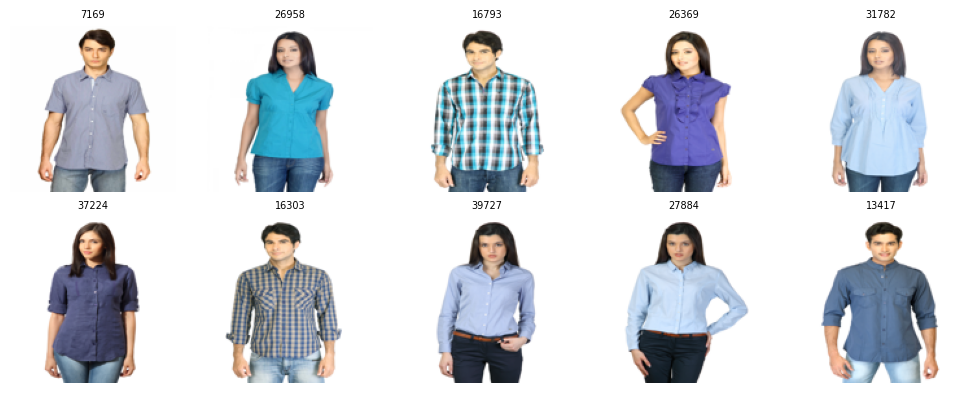

In [8]:
query = "blue casual shirt"   # Change this query whenever you want

results = search_images_by_text(query, top_k=10)

print(f"Search Query: {query}")
show_search_results_grid(results, thumb_size=(128, 128), rows=2, cols=5)